# Setup

In [468]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from IPython.display import display, Markdown

In [469]:
seed = 1
torch.manual_seed(seed)

In [470]:
batch_size = 16
EPOCHS = 70
seq_length = 3
LR = 0.0003
hidden_size = 32
device = torch.device("cpu")
shuffle_train = True

# Data

In [471]:


ticker = "EURUSD=X"
df = yf.download(ticker, start="2003-12-01", end="2025-03-01", interval="1d")
df = pd.DataFrame(df).drop(columns=['Volume']) # car y a que des 0
df.columns = [col[0] for col in df.columns]
df = df.reset_index()

[*********************100%***********************]  1 of 1 completed


In [472]:
df = df[['Date', 'Open', 'High', 'Low', 'Close']] #just for lisibility
df.head()

,Date,Open,High,Low,Close
0,2003-12-01,1.203398,1.204007,1.194401,1.196501
1,2003-12-02,1.196101,1.210903,1.194600,1.208897
2,2003-12-03,1.209000,1.213003,1.207700,1.212298
3,2003-12-04,1.212004,1.214403,1.204398,1.208094
4,2003-12-05,1.207802,1.219096,1.206593,1.218695


In [473]:
features = ['Open', 'High', 'Low', 'Close'] #open must be first
target = 'Close'

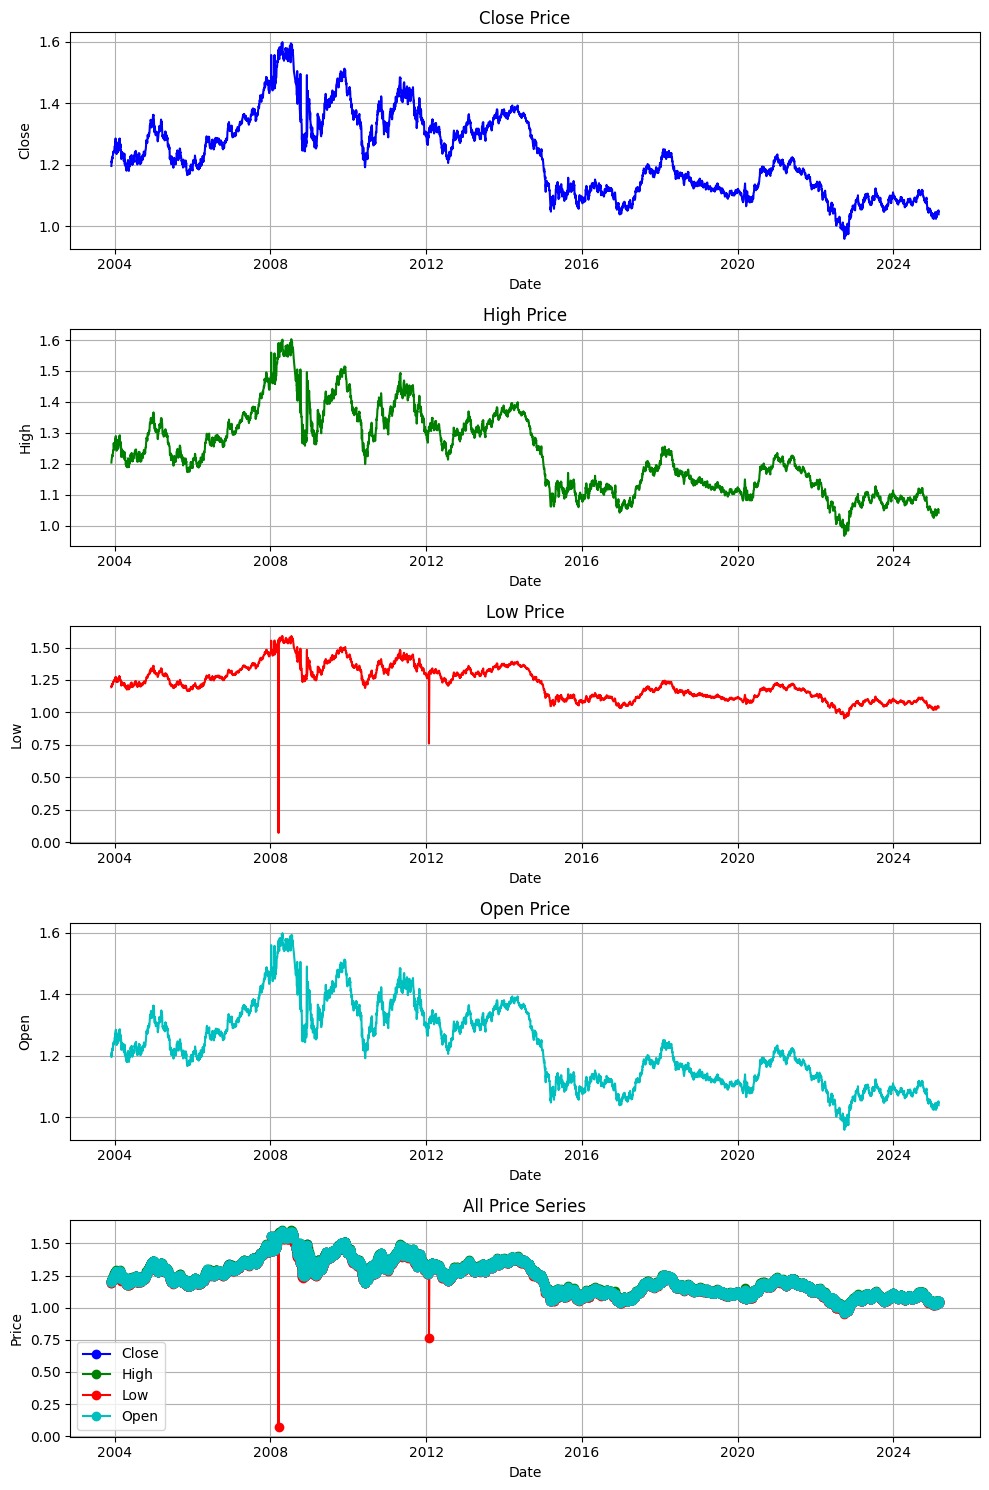

In [474]:
df['Date'] = pd.to_datetime(df['Date'])

# Create subplots
fig, axs = plt.subplots(5, 1, figsize=(10, 15))

# Plot each time series
axs[0].plot(df['Date'], df['Close'], label='Close', color='b')
axs[0].set_title('Close Price')
axs[0].set_xlabel('Date')
axs[0].set_ylabel('Close')
axs[0].grid(True)

axs[1].plot(df['Date'], df['High'], label='High', color='g')
axs[1].set_title('High Price')
axs[1].set_xlabel('Date')
axs[1].set_ylabel('High')
axs[1].grid(True)

axs[2].plot(df['Date'], df['Low'], label='Low', color='r')
axs[2].set_title('Low Price')
axs[2].set_xlabel('Date')
axs[2].set_ylabel('Low')
axs[2].grid(True)

axs[3].plot(df['Date'], df['Open'], label='Open', color='c')
axs[3].set_title('Open Price')
axs[3].set_xlabel('Date')
axs[3].set_ylabel('Open')
axs[3].grid(True)

# Plot the entire dataframe for reference
axs[4].plot(df['Date'], df['Close'], label='Close', color='b', linestyle='-', marker='o')
axs[4].plot(df['Date'], df['High'], label='High', color='g', linestyle='-', marker='o')
axs[4].plot(df['Date'], df['Low'], label='Low', color='r', linestyle='-', marker='o')
axs[4].plot(df['Date'], df['Open'], label='Open', color='c', linestyle='-', marker='o')
axs[4].set_title('All Price Series')
axs[4].set_xlabel('Date')
axs[4].set_ylabel('Price')
axs[4].legend()
axs[4].grid(True)

# Adjust the layout
plt.tight_layout()
plt.show()


In [475]:
full_dataframe_size = len(df)
train_dataframe_size = int(full_dataframe_size * 0.8)

train_dataframe = df[:train_dataframe_size]
test_dataframe = df[train_dataframe_size-seq_length:] # we take the last seq_length of the train dataset to start testing at the start of the test dataset. 
#these seq_length values wont be infered (see SequenceDataset class)

In [476]:
class SequenceDataset(Dataset):
    """
    Dataset for time series data
    target is a float
    input is a vector of size nb_features*seq_length + 1 : it contains the features of the previous seq_length days and the open price of the current day
    """
    def __init__(self, dataframe, seq_length, target, features):
        self.dataframe = dataframe
        self.seq_length = seq_length
        self.target = target
        self.features = features

        self.x = torch.tensor(self.dataframe[self.features].values, dtype=torch.float32)
        self.y = torch.tensor(self.dataframe[self.target].values, dtype=torch.float32)

        super().__init__()

    def __len__(self):
        return len(self.dataframe) - self.seq_length
    
    def __getitem__(self, idx):
        df_idx = idx + self.seq_length # we start reading the dataframe at idx + seq_length to ensure we can always read seq_length days before the current day

        x = self.x[df_idx - self.seq_length:df_idx]
        x = x.flatten()
        opentoday = self.x[df_idx][0]
        x = torch.cat((x, opentoday.view(-1)), 0)
        y = self.y[df_idx]

        return x, y

In [477]:
train_dataset = SequenceDataset(train_dataframe, seq_length, target, features)
test_dataset = SequenceDataset(test_dataframe, seq_length, target, features)
full_dataset = SequenceDataset(df, seq_length, target, features)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
full_loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=False)

# Testing and plotting functions

In [ ]:
def print_mse(mse, message) :

    display(Markdown(f'# <span style="font-size: 24px;">{message} : {mse}</span>'))

In [479]:
def infer(model, loader):
    model.eval()
    y_pred = []
    y_true = []
    
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            
            preds = model(x)
            
            # Store predictions and labels
            y_pred.append(preds)
            y_true.append(y)
    
    y_pred = torch.cat(y_pred, dim=0)
    y_true = torch.cat(y_true, dim=0)
    
    return y_pred, y_true

In [480]:
def plot_time_series(pred, true, start, end, title,vlinesplit=None):
    plt.plot(pred[start:end], label='Prediction', color='r')
    plt.plot(true[start:end], label='True', color='b')
    if vlinesplit is not None:
        plt.axvline(x=vlinesplit, color='g', linestyle='--', label='Testing start')
    plt.title(title)
    plt.legend()
    plt.show()

def plot_full_time_series(pred, true, title) :
    end = len(df) - seq_length
    vlinesplit = train_dataframe_size - seq_length
    plot_time_series(pred, true, 0, end, title, vlinesplit=vlinesplit)

In [481]:
def plot_loss(loss_per_epoch, title, remove_first = False):
    x = range(1, len(loss_per_epoch) + 1)

    if remove_first :
        x = range(2, len(loss_per_epoch) + 1)
        loss_per_epoch = loss_per_epoch[1:]

    plt.plot(x, loss_per_epoch)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.show()

In [482]:
def computeMSE(pred, true):
    mse = nn.MSELoss()
    return mse(pred, true)

# Training function

In [483]:
def train(model, train_loader, test_loader, optimizer, loss_func, EPOCHS):
    train_losses = []
    test_losses = []

    for epoch in range(EPOCHS):

        model.train()
        epoch_train_loss = 0

        for x, y in train_loader:
            optimizer.zero_grad()
            y_pred = model(x)
            loss = loss_func(y_pred, y)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()
        train_losses.append(epoch_train_loss / len(train_loader)) # len(train_loader) is the number of batches

        model.eval()
        with torch.no_grad():

            epoch_test_loss = 0

            for x, y in test_loader:
                y_pred = model(x)
                loss = loss_func(y_pred, y)
                epoch_test_loss += loss.item()
        test_losses.append(epoch_test_loss / len(test_loader))

    return train_losses, test_losses

# Models definition

### Last value

In [484]:
class LastValue(nn.Module):
    def forward(self, x):
        return x[:, -2] # -1 is the open of today, -2 is the close of yesterday

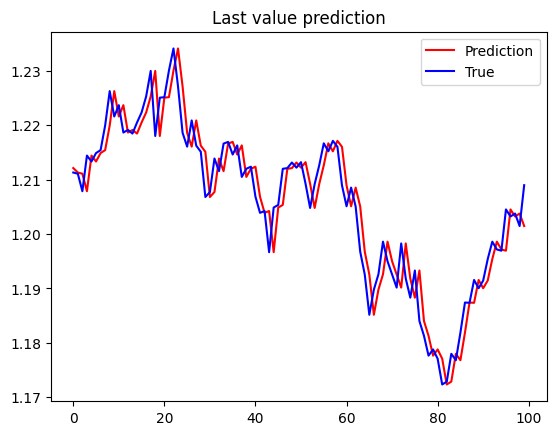

In [485]:
last_value = LastValue()

pred, true = infer(last_value, test_loader)
plot_time_series(pred, true, 0, 100, 'Last value prediction')

In [486]:
mse = computeMSE(pred, true)
print_mse(mse, "Last value test MSE")

# <span style="font-size: 24px;">Last value test MSE: 2.503290852473583e-05</span>

### LSTM

In [487]:
class ClassicalLSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.input_gate = nn.Linear(input_size + hidden_size, hidden_size)
        self.forget_gate = nn.Linear(input_size + hidden_size, hidden_size)
        self.output_gate = nn.Linear(input_size + hidden_size, hidden_size)
        self.state_gate = nn.Linear(input_size + hidden_size, hidden_size)

    def forward(self, x, hc):
        """
        x shape : (batch_size, input_size)
        h shape : (batch_size, hidden_size)
        c shape : (batch_size, hidden_size)
        """
        h, c = hc
        xh = torch.cat((x, h), 1)

        input_value = torch.sigmoid(self.input_gate(xh))
        forget_value = torch.sigmoid(self.forget_gate(xh))
        output_value = torch.sigmoid(self.output_gate(xh))
        state_value = torch.tanh(self.state_gate(xh))

        newc = forget_value * c + input_value * state_value
        newh = output_value * torch.tanh(newc)

        return newh, newc # newh shape : (batch_size, hidden_size), newc shape : (batch_size, hidden_size)
    
class ClassicalLSTM(nn.Module):
    def __init__(self, num_features, hidden_size, device, seq_length):
        super().__init__()
        self.num_features = num_features
        self.hidden_size = hidden_size
        self.device = device
        self.seq_length = seq_length
        
        self.cell = ClassicalLSTMCell(self.num_features, hidden_size)
        self.finalLinear = nn.Linear(hidden_size + 1, 1)

    def forward(self, x): # x shape : (batch_size, seq_length*num_features+1)
        opentoday = x[:, -1] # opentoday shape : (batch_size, 1)
        opentoday = opentoday.reshape(-1, 1)

        x = x[:, :-1] # x shape : (batch_size, seq_length*num_features)
        x = x.reshape(-1, self.seq_length, self.num_features) # x shape : (batch_size, seq_length, num_features)

        batch_size = x.size(0)

        h = torch.zeros(batch_size, self.hidden_size, dtype=torch.float32, device=self.device)
        c = torch.zeros(batch_size, self.hidden_size, dtype=torch.float32, device=self.device)

        for i in range(self.seq_length):
            h, c = self.cell(x[:,i,:], (h, c)) # h shape : (batch_size, hidden_size), c shape : (batch_size, hidden_size)

        a = torch.cat((h, opentoday), 1) # a shape : (batch_size, hidden_size + 1)
        a = self.finalLinear(a) # a shape : (batch_size, 1)
        return a.flatten()

In [488]:
num_features = len(features)

lstm = ClassicalLSTM(num_features, hidden_size, device, seq_length)

In [489]:
x, y = next(iter(train_loader))

print(x.shape)
print(y.shape)

pred = lstm(x)
print(pred.shape)

torch.Size([16, 13])
torch.Size([16])
torch.Size([16])


# Training

In [490]:
optimizer = torch.optim.Adam(lstm.parameters(), lr=LR)
loss_func = nn.MSELoss()

In [ ]:
pred, true = infer(lstm, test_loader)
mse = computeMSE(pred, true)

print_mse(mse, "Test MSE before training")

Test MSE before training: 0.6883025765419006


In [492]:
train_losses, test_losses = train(lstm, train_loader, test_loader, optimizer, loss_func, EPOCHS)

In [493]:
pred, true = infer(lstm, test_loader)
mse = computeMSE(pred, true)

print_mse(mse, "Test MSE after training")

# <span style="font-size: 24px;">Test MSE after training: 3.385417949175462e-05</span>

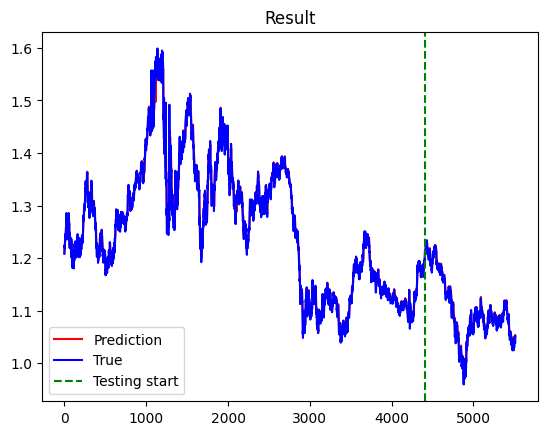

In [494]:
pred, true = infer(lstm, full_loader)

plot_full_time_series(pred, true, "Result")

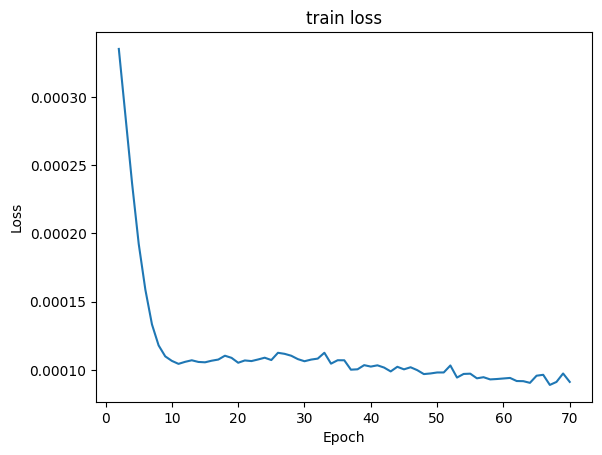

In [495]:
plot_loss(train_losses, "train loss", remove_first=True)